30 Days Hospital Readmission Prediction
Dataset: Diabetes 130 Us Hospitals for years 1999-2008 (UCI ML Repository Id 296)

In [86]:
# Import important libraties
import os
import numpy as np
import pandas as pd
# matplotlib.use ("Agg")
import matplotlib.pyplot


In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [88]:
DATA_PATH = "data/diabetic_data.csv"   # where your CSV lives
TEST_SIZE = 0.20                       # 20% of data held out for testing
RANDOM_SEED = 42    

In [89]:
diabetes_df = pd.read_csv(
    DATA_PATH,
    keep_default_na=False,
    na_values=["?", "Unknown/Invalid", ""],
    low_memory=False,   # silences a harmless warning about mixed column types
)

In [90]:
# Make the output folders if they don't exist yet
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [91]:
print("\nSTEP 1: Loading the data")



STEP 1: Loading the data


In [92]:
# --- Filter A: remove patients who died or went to hospice -----------------
# A patient who died cannot be readmitted. If we leave these rows in, we are
# asking the model to predict something that was never possible.
# The column discharge_disposition_id is a code. Codes 11, 13, 14, 19, 20, 21
# all mean died or hospice.
rows_before = len(diabetes_df)
died_or_hospice = [11, 13, 14, 19, 20, 21]
diabetes_df = diabetes_df[~diabetes_df["discharge_disposition_id"].isin(died_or_hospice)]
print(f"  Removed {rows_before - len(diabetes_df):,} expired/hospice encounters")

  Removed 2,423 expired/hospice encounters


In [93]:
#--- Filter B: keep only each patient's FIRST hospital visit ---------------
# THIS IS THE MOST IMPORTANT LINE IN THE WHOLE SCRIPT.
#
# The same patient can appear several times in this file (about 30% do).
# If patient #12345 shows up in both our training data and our testing data,
# the model can just memorize that patient instead of learning what makes
# someone likely to be readmitted. Our test scores would look great but be
# completely fake. This is called DATA LEAKAGE.
#
# Sorting by encounter_id puts each patient's visits in time order, then
# drop_duplicates(keep="first") keeps only the earliest on

rows_before = len(diabetes_df)
diabetes_df = diabetes_df.sort_values("encounter_id")
diabetes_df = diabetes_df.drop_duplicates(subset="patient_nbr", keep="first")
print(f"  Removed {rows_before - len(diabetes_df):,} repeat visits (kept first per patient)")
print(f"  Final cohort: {len(diabetes_df):,} rows, one per unique patient")

  Removed 29,353 repeat visits (kept first per patient)
  Final cohort: 69,990 rows, one per unique patient


In [94]:
# The "readmitted" column has three possible values:
#     "<30"  = came back within 30 days
#     ">30"  = came back, but after 30 days
#     "NO"   = did not come back
#
# Our research question is only about 30 days, so we turn this into a yes/no:
#     1 = readmitted within 30 days
#     0 = everything else
diabetes_df["target"] = (diabetes_df["readmitted"] == "<30").astype(int)
n_yes = diabetes_df["target"].sum()
n_no = len(diabetes_df) - n_yes
percent_yes = n_yes / len(diabetes_df) * 100

In [95]:
print(f"  Readmitted within 30 days: {n_yes:,} ({percent_yes:.1f}%)")
print(f"  Not readmitted:            {n_no:,} ({100 - percent_yes:.1f}%)")
print(f"  >>> This is IMBALANCED - about {n_no / n_yes:.0f} 'no' for every 'yes'")

  Readmitted within 30 days: 6,285 (9.0%)
  Not readmitted:            63,705 (91.0%)
  >>> This is IMBALANCED - about 10 'no' for every 'yes'


In [96]:
import matplotlib.pyplot as plt

In [97]:
# Chart 1: show the imbalance. Use this on a slide - it sets up the whole
# argument about why accuracy is a misleading metric here.
plt.figure(figsize=(5, 4))
plt.bar(["Not readmitted", "Readmitted <30 days"], [n_no, n_yes], color=["grey", "red"])
plt.ylabel("Number of patients")
plt.title("Class imbalance in our target")
plt.tight_layout()
plt.savefig("figures/01_class_balance.png", dpi=150)
plt.close()
print("  Saved figures/01_class_balance.png")

  Saved figures/01_class_balance.png


## Step 4: Check Missing Data — Report Section 3b

Before deciding what to do, look at how much is missing and where.

In [98]:
missing_percent = diabetes_df.isna().mean().mul(100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing_percent.round(1)

weight               96.0
medical_specialty    48.1
payer_code           43.5
race                  2.7
diag_3                1.7
diag_2                0.4
diag_1                0.0
gender                0.0
dtype: float64

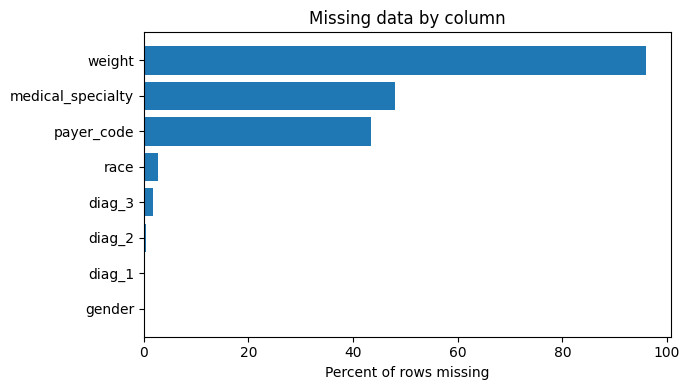

In [99]:
plt.figure(figsize=(7, 4))
plt.barh(missing_percent.index[::-1], missing_percent.values[::-1])
plt.xlabel("Percent of rows missing")
plt.title("Missing data by column")
plt.tight_layout()
plt.savefig("figures/02_missing_data.png", dpi=150)
plt.show()

## Step 5: Handle Missing Data — Report Section 3b

Each column handled on purpose. We don't delete rows just for being
incomplete — that would quietly drop a non-random group of patients.

In [100]:
# weight: 96% missing. Drop it, but keep whether it was recorded at all.
diabetes_df["weight_was_recorded"] = diabetes_df["weight"].notna().astype(int)
diabetes_df = diabetes_df.drop(columns=["weight"])

# payer_code: billing info, not medical.
diabetes_df = diabetes_df.drop(columns=["payer_code"])

# medical_specialty and race: blanks aren't random, so "Missing" becomes
# its own category rather than guessing a value.
diabetes_df["medical_specialty"] = diabetes_df["medical_specialty"].fillna("Missing")
diabetes_df["race"] = diabetes_df["race"].fillna("Missing")

# gender: a handful of invalid entries, small enough to drop.
diabetes_df = diabetes_df[diabetes_df["gender"].notna()]

diabetes_df.shape

(69987, 50)

In [101]:
# Confirm what's left
diabetes_df.isna().mean().mul(100).round(1).sort_values(ascending=False).head()

diag_3         1.7
diag_2         0.4
patient_nbr    0.0
race           0.0
age            0.0
dtype: float64

## Step 6: Feature Engineering and Outliers — Report Section 3b

Four things: convert age to numbers, group the diagnosis codes,
add a combined visits column, and cap extreme values.

In [102]:
# 'age' arrives as text like "[70-80)". Replace each bracket with its midpoint.
age_midpoints = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
    "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95,
}
diabetes_df["age_number"] = diabetes_df["age"].map(age_midpoints)

diabetes_df["age_number"].describe()

count    69987.000000
mean        65.442511
std         15.974161
min          5.000000
25%         55.000000
50%         65.000000
75%         75.000000
max         95.000000
Name: age_number, dtype: float64

In [103]:
def group_diagnosis(code):
    """Turn one ICD-9 code into a broad category name."""
    if pd.isna(code):
        return "Missing"

    code = str(code)
    if code.startswith("V"):
        return "Other"
    if code.startswith("E"):
        return "Injury"

    try:
        number = float(code)
    except ValueError:
        return "Other"

    if 250 <= number < 251:
        return "Diabetes"
    if 390 <= number <= 459:
        return "Circulatory"
    if 460 <= number <= 519:
        return "Respiratory"
    if 520 <= number <= 579:
        return "Digestive"
    if 580 <= number <= 629:
        return "Genitourinary"
    if 710 <= number <= 739:
        return "Musculoskeletal"
    if 800 <= number <= 999:
        return "Injury"
    if 140 <= number <= 239:
        return "Cancer"
    return "Other"

In [104]:
for column in ["diag_1", "diag_2", "diag_3"]:
    diabetes_df[column + "_group"] = diabetes_df[column].apply(group_diagnosis)

diabetes_df = diabetes_df.drop(columns=["diag_1", "diag_2", "diag_3"])

diabetes_df["diag_1_group"].value_counts()

diag_1_group
Circulatory        21321
Other              15419
Respiratory         6451
Digestive           6326
Diabetes            5748
Injury              4695
Musculoskeletal     4064
Genitourinary       3415
Cancer              2538
Missing               10
Name: count, dtype: int64

In [105]:
diabetes_df["total_prior_visits"] = (
    diabetes_df["number_outpatient"]
    + diabetes_df["number_emergency"]
    + diabetes_df["number_inpatient"]
)

diabetes_df["total_prior_visits"].describe()

count    69987.000000
mean         0.559775
std          1.427772
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         49.000000
Name: total_prior_visits, dtype: float64

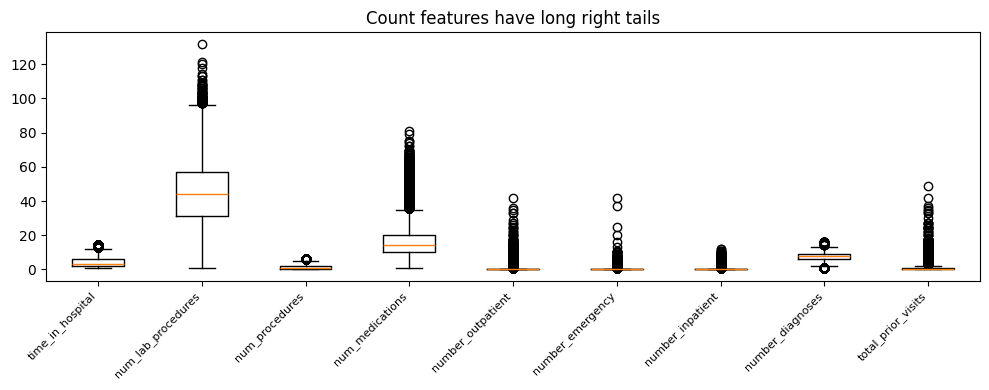

In [106]:
count_columns = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses", "total_prior_visits",
]

plt.figure(figsize=(10, 4))
plt.boxplot([diabetes_df[c] for c in count_columns])
plt.xticks(range(1, len(count_columns) + 1), count_columns, rotation=45, ha="right", fontsize=8)
plt.title("Count features have long right tails")
plt.tight_layout()
plt.savefig("figures/03_outliers.png", dpi=150)
plt.show()

In [107]:
# Some patients have 40+ prior visits. Those are real very sick patients,
# not typos — so cap them rather than delete them. Deleting would remove
# exactly the high-risk people the model most needs to learn from.
for column in count_columns:
    cap = diabetes_df[column].quantile(0.99)
    diabetes_df[column] = diabetes_df[column].clip(upper=cap)

diabetes_df[count_columns].describe().round(1)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,total_prior_visits
count,69987.0,69987.0,69987.0,69987.0,69987.0,69987.0,69987.0,69987.0,69987.0
mean,4.3,42.8,1.4,15.6,0.2,0.1,0.2,7.2,0.5
std,2.9,19.7,1.8,7.9,0.7,0.3,0.5,2.0,1.1
min,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
25%,2.0,31.0,0.0,10.0,0.0,0.0,0.0,6.0,0.0
50%,3.0,44.0,1.0,14.0,0.0,0.0,0.0,8.0,0.0
75%,6.0,57.0,2.0,20.0,0.0,0.0,0.0,9.0,1.0
max,13.0,85.0,6.0,44.0,4.0,2.0,3.0,9.0,6.0


## Step 7: Prepare the Final Table — Report Section 3c

Drop columns the model shouldn't see, then convert text to numbers.

In [108]:
# encounter_id and patient_nbr are ID numbers — meaningless as predictors.
# readmitted IS the answer, so keeping it would be cheating.
# age is replaced by age_number.
diabetes_df = diabetes_df.drop(
    columns=["encounter_id", "patient_nbr", "readmitted", "age"]
)

# These look like numbers but are really category codes —
# admission type "1" isn't half of "2".
for column in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    diabetes_df[column] = diabetes_df[column].astype(str)

diabetes_df.shape

(69987, 48)

In [109]:
y = diabetes_df["target"]
X = diabetes_df.drop(columns=["target"])

# Models only understand numbers. get_dummies turns a text column like
# "gender" into 0/1 columns. This is called one-hot encoding.
X = pd.get_dummies(X, drop_first=True)

X.shape

(69987, 210)

## Step 8: Train/Test Split — Report Section 3c

Train on 80% of patients, test on the 20% the model has never seen.

In [110]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the same ~9% readmission rate in both halves.
# Without it, random chance could give us a test set with hardly any.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(f"Training: {len(X_train):,} patients ({y_train.mean():.1%} readmitted)")
print(f"Testing:  {len(X_test):,} patients ({y_test.mean():.1%} readmitted)")

Training: 55,989 patients (9.0% readmitted)
Testing:  13,998 patients (9.0% readmitted)


In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(55989, 210)

## Step 9: Train the Models — Report Section 2

Four models. The first one is deliberately useless — it exists to prove
a point about accuracy in Step 11.

class_weight="balanced" tells each model to pay ~10x more attention to the
rare readmitted patients. Without it, a model can score well just by
saying "nobody comes back" every time.

In [112]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Baseline (always says no)": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,              # shallow, so it can't just memorize
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,         # 300 trees voting together
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
    ),
}

In [113]:
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Logistic regression uses the scaled data; trees don't need scaling.
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        predictions[name] = model.predict(X_test_scaled)
        probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        predictions[name] = model.predict(X_test)
        probabilities[name] = model.predict_proba(X_test)[:, 1]

print("Done")

Training Baseline (always says no)...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Done


## Step 10: Evaluation — Report Section 4a

What each metric means:

- **Accuracy** — of all patients, how many did we label correctly?
- **Precision** — of the patients we flagged, how many really came back?
- **Recall** — of the patients who really came back, how many did we catch?
- **F1** — one number balancing precision and recall.
- **ROC-AUC** — pick one readmitted and one not-readmitted patient at random;
  how often does the model score the readmitted one higher? 0.5 is a coin flip.

In [114]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
)

results = []
for name in models:
    pred = predictions[name]
    prob = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, prob), 4),
    })

results_table = pd.DataFrame(results)
results_table.to_csv("results/model_scores.csv", index=False)

results_table

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline (always says no),0.9102,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.6620,0.1389,0.5314,0.2202,0.6505
2,Decision Tree,0.7357,0.1531,0.4288,0.2257,0.6233
3,Random Forest,0.7115,0.1521,0.4837,0.2314,0.6506


## Step 11: Charts — Report Section 4a

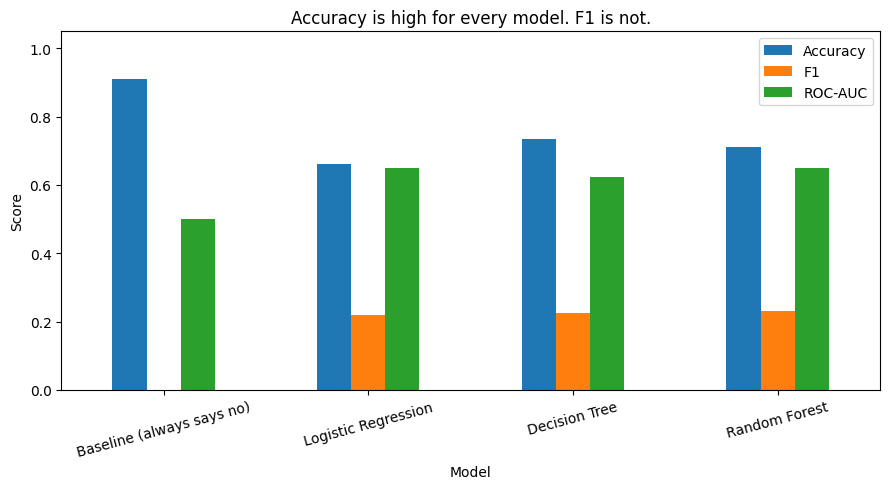

In [115]:
plot_data = results_table.set_index("Model")[["Accuracy", "F1", "ROC-AUC"]]
plot_data.plot(kind="bar", figsize=(9, 5), rot=15)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Accuracy is high for every model. F1 is not.")
plt.tight_layout()
plt.savefig("figures/04_model_comparison.png", dpi=150)
plt.show()

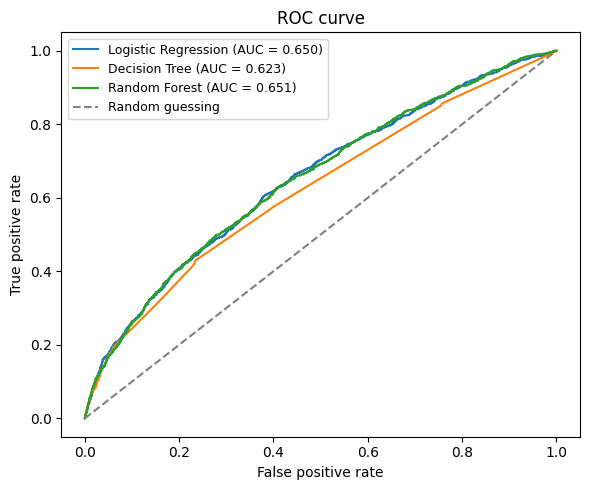

In [116]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(6, 5))
for name in models:
    if name == "Baseline (always says no)":
        continue
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="grey", label="Random guessing")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/05_roc_curve.png", dpi=150)
plt.show()

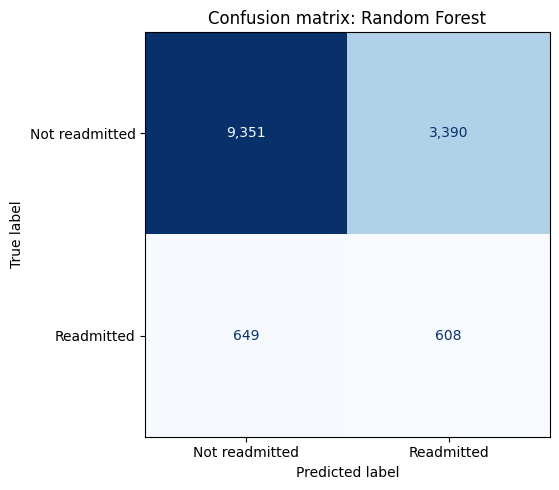

Caught 608 readmissions, missed 649, raised 3,390 false alarms


In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = "Random Forest"
cm = confusion_matrix(y_test, predictions[best_name])

plt.figure(figsize=(5.5, 5))
ConfusionMatrixDisplay(
    cm, display_labels=["Not readmitted", "Readmitted"]
).plot(cmap="Blues", colorbar=False, values_format=",d", ax=plt.gca())
plt.title(f"Confusion matrix: {best_name}")
plt.grid(False)
plt.tight_layout()
plt.savefig("figures/06_confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Caught {tp:,} readmissions, missed {fn:,}, raised {fp:,} false alarms")

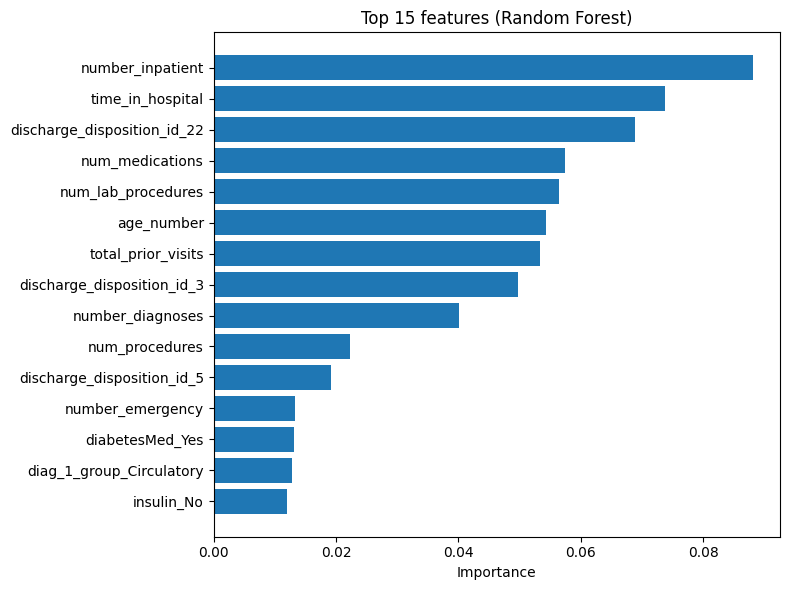

In [118]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": models[best_name].feature_importances_,
}).sort_values("importance", ascending=False).head(15)

importance.to_csv("results/feature_importance.csv", index=False)

plt.figure(figsize=(8, 6))
plt.barh(importance["feature"][::-1], importance["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Top 15 features ({best_name})")
plt.tight_layout()
plt.savefig("figures/07_feature_importance.png", dpi=150)
plt.show()

## Step 12: Analysis and Conclusions — Report Section 4b

In [119]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions[best_name]).ravel()
best = results_table[results_table["Model"] == best_name].iloc[0]

print(f"""
1. ACCURACY IS THE WRONG METRIC HERE.
   A model that says "not readmitted" for everyone scores 91.0% accuracy
   and catches ZERO readmissions. Any model has to beat that to mean
   anything, and accuracy alone cannot tell us whether it did.

2. OUR BEST MODEL: {best_name}
   ROC-AUC  {best['ROC-AUC']:.3f}   (0.5 = coin flip)
   F1       {best['F1']:.3f}
   Recall   {best['Recall']:.3f}   <- fraction of real readmissions caught
   Better than chance, but not close to perfect.

3. WHY IT ISN'T MORE ACCURATE - AND WHY THAT IS A FINDING.
   Published research on this dataset also lands around 0.65-0.70 ROC-AUC.
   The strongest causes of readmission are things a hospital billing record
   never captures: stable housing, someone at home to help, transportation
   to a follow-up appointment, money for prescriptions. We can only model
   what was written down.

4. WHAT ACTUALLY PREDICTS READMISSION.
   Prior inpatient visits ranked first - the best predictor of coming back
   is having been there before. Three discharge disposition codes also made
   the top 15, meaning WHERE a patient goes after leaving (rehab, skilled
   nursing, another facility) matters more than most clinical details.

5. THE ERRORS ARE NOT EQUALLY BAD.
   We caught {tp:,} readmissions, missed {fn:,}, and raised {fp:,} false alarms.
   A missed readmission is a patient who goes home with no follow-up care.
   A false alarm is a phone call from a nurse.

6. LIMITATIONS.
   - Data is from 1999-2008; medical practice has changed since.
   - Diabetic inpatients only, so it does not generalize to all patients.
   - Readmission to a DIFFERENT hospital is recorded as "not readmitted",
     so some of our negatives are actually positives.
""")


1. ACCURACY IS THE WRONG METRIC HERE.
   A model that says "not readmitted" for everyone scores 91.0% accuracy
   and catches ZERO readmissions. Any model has to beat that to mean
   anything, and accuracy alone cannot tell us whether it did.

2. OUR BEST MODEL: Random Forest
   ROC-AUC  0.651   (0.5 = coin flip)
   F1       0.231
   Recall   0.484   <- fraction of real readmissions caught
   Better than chance, but not close to perfect.

3. WHY IT ISN'T MORE ACCURATE - AND WHY THAT IS A FINDING.
   Published research on this dataset also lands around 0.65-0.70 ROC-AUC.
   The strongest causes of readmission are things a hospital billing record
   never captures: stable housing, someone at home to help, transportation
   to a follow-up appointment, money for prescriptions. We can only model
   what was written down.

4. WHAT ACTUALLY PREDICTS READMISSION.
   Prior inpatient visits ranked first - the best predictor of coming back
   is having been there before. Three discharge disposit